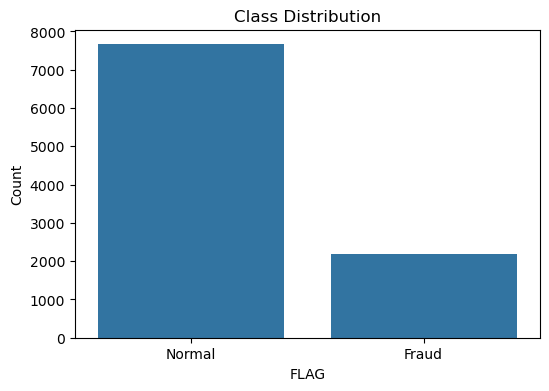

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cleaned_ethereum_data.csv")

# Target variable
y = df['FLAG']

# ============================================================================
# CLASS DISTRIBUTION
# ============================================================================

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.ylabel("Count")

# Lưu hình
plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

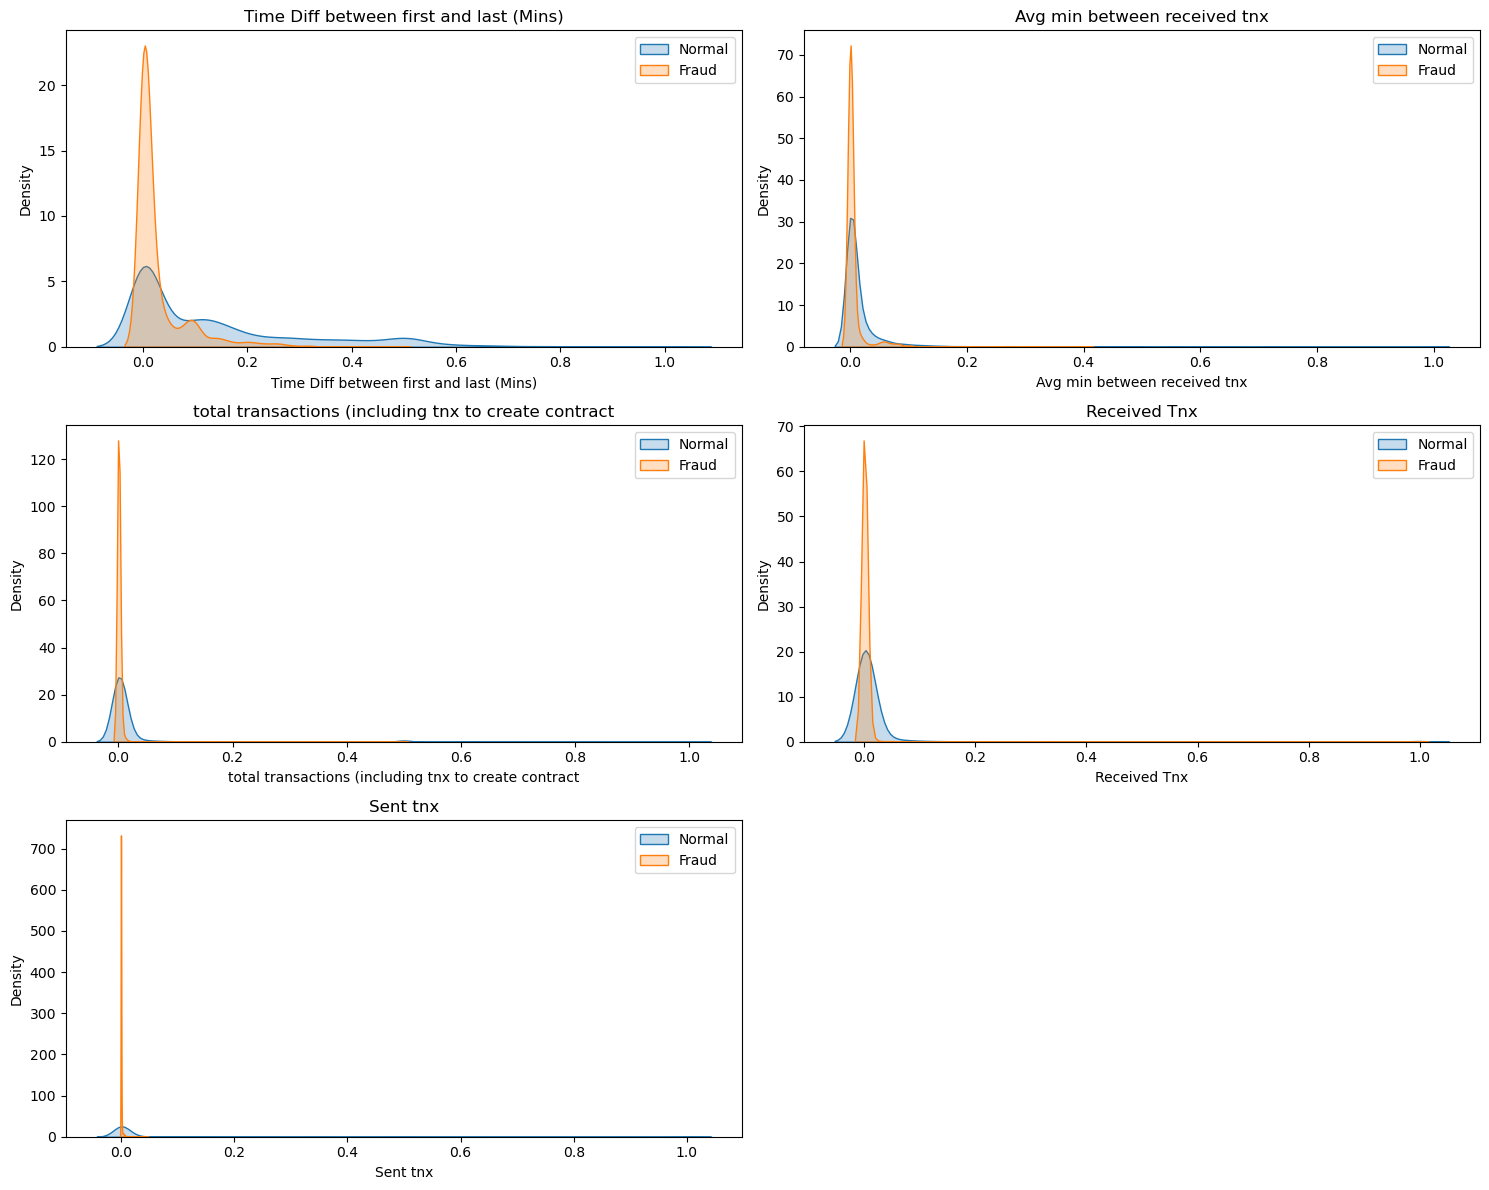

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cleaned_ethereum_data.csv")

# Remove extra spaces
df.columns = df.columns.str.strip()

# Top 5 features
top_5 = [
    'Time Diff between first and last (Mins)',
    'Avg min between received tnx',
    'total transactions (including tnx to create contract',
    'Received Tnx',
    'Sent tnx',
]

# ============================================================================
# DISTRIBUTION VISUALIZATION
# ============================================================================

# Create subplot: 3 rows x 2 columns
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Flatten axes array
axes = axes.flatten()

for i, col in enumerate(top_5):

    sns.kdeplot(
        df[df['FLAG'] == 0][col],
        label='Normal',
        fill=True,
        ax=axes[i]
    )

    sns.kdeplot(
        df[df['FLAG'] == 1][col],
        label='Fraud',
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col}")
    axes[i].legend()

# Remove empty subplot
fig.delaxes(axes[5])

# Auto spacing
plt.tight_layout()

# Save all charts into one image
plt.savefig("distribution_visualization.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

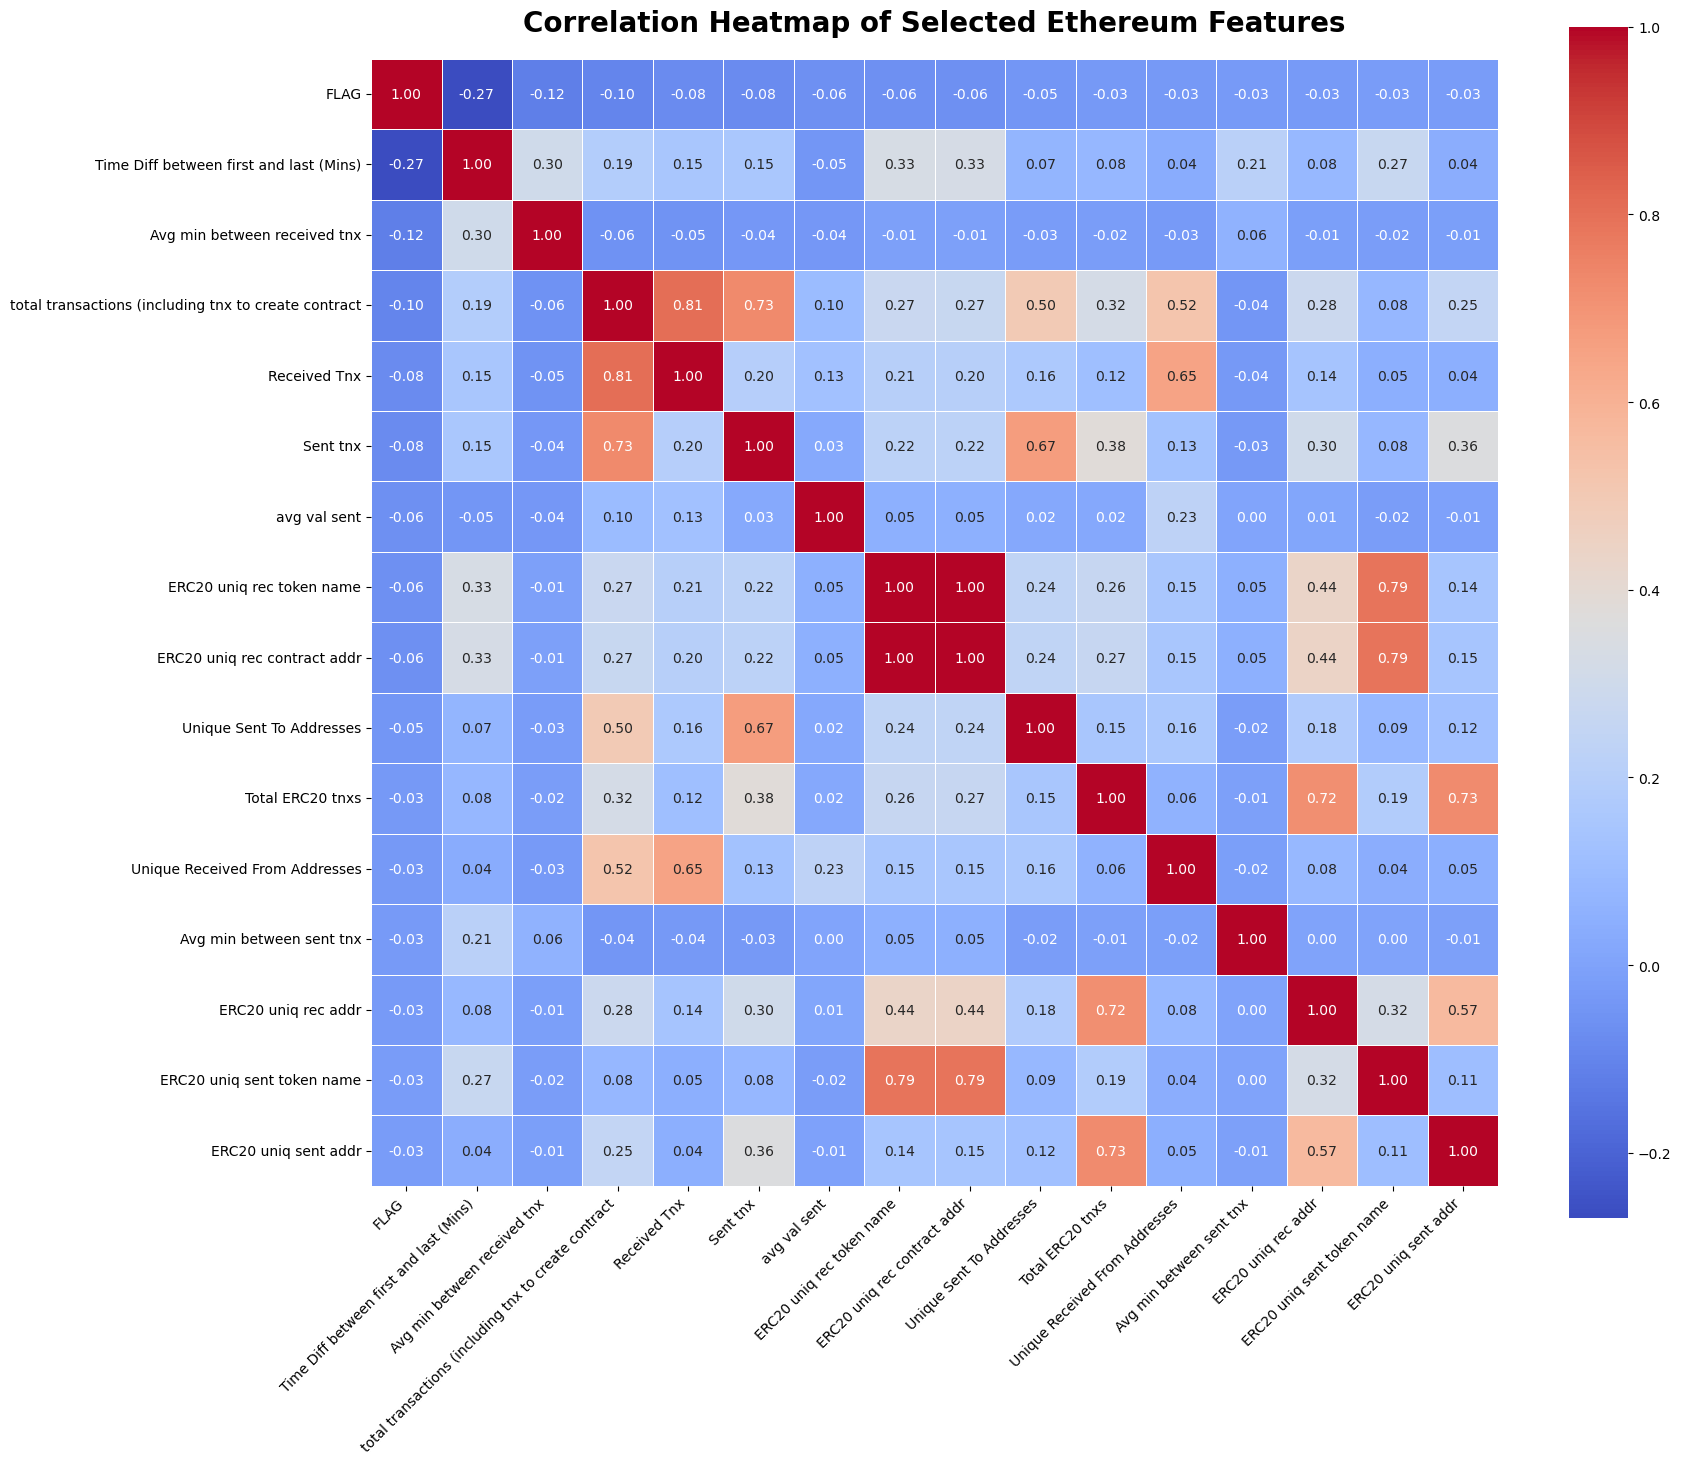

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###Correlation Heatmap

# =========================
# Load Dataset
# =========================
df = pd.read_csv('cleaned_ethereum_data.csv')

# remove extra spaces in column names
df.columns = df.columns.str.strip()

# fill missing values
df = df.fillna(0)

# =========================
# Remove useless columns
# =========================

# remove columns with only one unique value
single_val_cols = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

df = df.drop(columns=single_val_cols)

# keep only numeric columns
df_numeric = df.select_dtypes(include=['number'])

# =========================
# Correlation Matrix
# =========================
corr_matrix = df_numeric.corr()

# =========================
# Selected Features
# =========================
selected_features = [
    'FLAG',
    'Time Diff between first and last (Mins)',
    'Avg min between received tnx',
    'total transactions (including tnx to create contract',
    'Received Tnx',
    'Sent tnx',
    'avg val sent',
    'ERC20 uniq rec token name',
    'ERC20 uniq rec contract addr',
    'Unique Sent To Addresses',
    'Total ERC20 tnxs',
    'Unique Received From Addresses',
    'Avg min between sent tnx',
    'ERC20 uniq rec addr',
    'ERC20 uniq sent token name',
    'ERC20 uniq sent addr'
]

# =========================
# Check Missing Features
# =========================
missing_features = [
    feature for feature in selected_features
    if feature not in corr_matrix.columns
]

if missing_features:
    print("Missing Features:")
    for feature in missing_features:
        print("-", feature)

    raise ValueError("Some required features are missing.")

# =========================
# Extract Correlation Data
# =========================
corr_selected = corr_matrix.loc[
    selected_features,
    selected_features
]

# =========================
# Plot Heatmap
# =========================
plt.figure(figsize=(18, 15))

sns.heatmap(
    corr_selected,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True
)

# title
plt.title(
    'Correlation Heatmap of Selected Ethereum Features',
    fontsize=20,
    weight='bold',
    pad=20
)

# axis style
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

# layout
plt.tight_layout()

# save image
plt.savefig(
    'ethereum_feature_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

# show plot
plt.show()

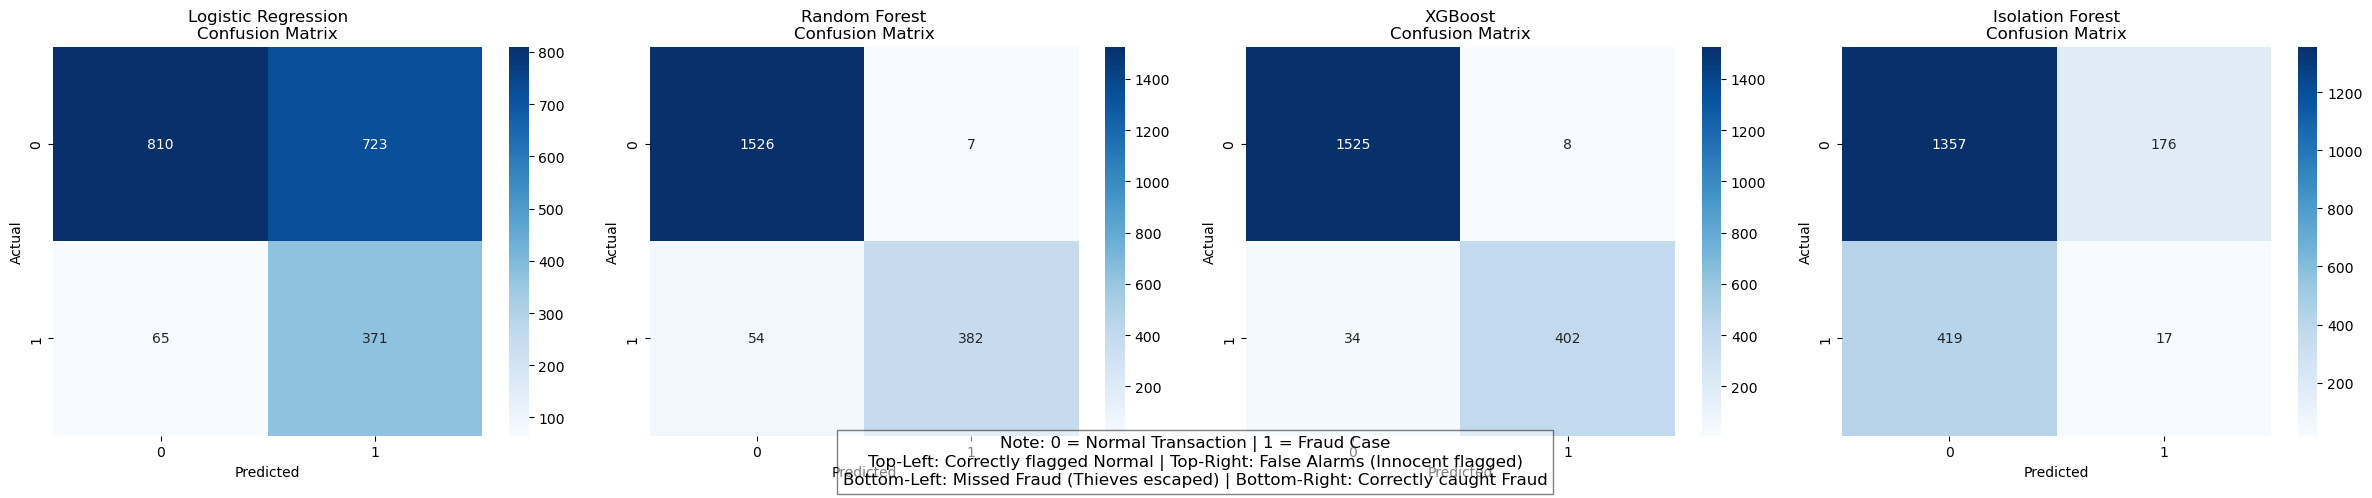


----4-models performance comparison----
                 Model  F1-Score  Precision    Recall  Accuracy
0  Logistic Regression  0.484967   0.339122  0.850917    0.5998
1        Random Forest  0.926061   0.982005  0.876147    0.9690
2              XGBoost  0.950355   0.980488  0.922018    0.9787
3     Isolation Forest  0.054054   0.088083  0.038991    0.6978

----XGB & RF performance based on features 3,5,15,all----
            Set         Model  F1-Score  Accuracy
 Top 3 Features       XGBoost    0.7512    0.8984
 Top 3 Features Random Forest    0.7638    0.9020
 Top 5 Features       XGBoost    0.7790    0.9081
 Top 5 Features Random Forest    0.7818    0.9101
Top 15 Features       XGBoost    0.8976    0.9563
Top 15 Features Random Forest    0.8791    0.9497
   All Features       XGBoost    0.9504    0.9787
   All Features Random Forest    0.9261    0.9690


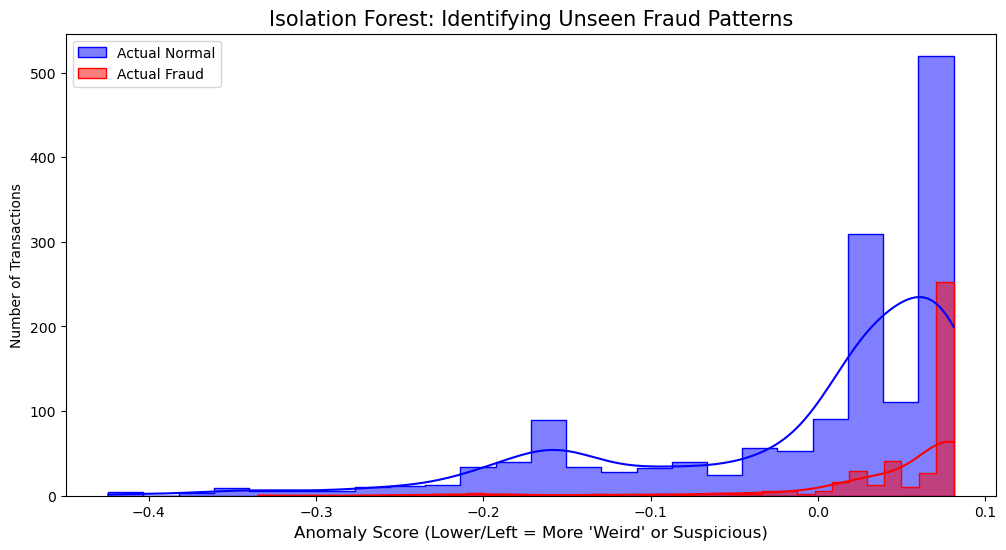

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

df = pd.read_csv('cleaned_ethereum_data.csv')

X = df.drop('FLAG', axis=1)
y = df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

# 4 models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),

    "Isolation Forest": IsolationForest(
        contamination=0.1,
        random_state=42
    )
}

# Storage for results
model_performance = []
cms = []

# ==============================
# CONFUSION MATRICES
# ==============================

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (name, model) in enumerate(models.items()):

    if name == "Isolation Forest":

        model.fit(X_train)

        y_pred = [1 if p == -1 else 0 for p in model.predict(X_test)]

        if_scores = model.decision_function(X_test_scaled)

    elif name == "Logistic Regression":

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

    # Detailed Reports
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    model_performance.append({
        "Model": name,
        "F1-Score": report['1']['f1-score'],
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "Accuracy": round(report['accuracy'], 4)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i]
    )

    axes[i].set_title(f"{name}\nConfusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Explanation Notes
fig.text(
    0.5,
    0.02,
    "Note: 0 = Normal Transaction | 1 = Fraud Case\n"
    "Top-Left: Correctly flagged Normal | Top-Right: False Alarms (Innocent flagged)\n"
    "Bottom-Left: Missed Fraud (Thieves escaped) | Bottom-Right: Correctly caught Fraud",
    ha='center',
    fontsize=12,
    bbox=dict(
        facecolor='white',
        alpha=0.5,
        edgecolor='black'
    )
)

plt.subplots_adjust(bottom=0.2)

# SAVE CONFUSION MATRIX
fig.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

# ==============================
# FEATURE TESTING
# ==============================

all_cols = X_train.columns.tolist()

# Helper to find exact column names
def get_col(keyword):

    match = [
        c for c in all_cols
        if keyword.lower() in c.lower()
    ]

    return match[0] if match else None

try:

    # Top 3
    top_3 = [
        get_col('Time Diff between first and last'),
        get_col('Avg min between received tnx'),
        get_col('total transactions (including tnx')
    ]

    # Top 5
    top_5 = top_3 + [
        get_col('Received Tnx'),
        get_col('Sent tnx')
    ]

    # Top 15
    top_15 = top_5 + [
        get_col('avg val sent'),
        get_col('ERC20 uniq rec token name'),
        get_col('ERC20 uniq rec contract addr'),
        get_col('Unique Sent To Addresses'),
        get_col('Total ERC20 tnxs'),
        get_col('Unique Received From Addresses'),
        get_col('Avg min between sent tnx'),
        get_col('ERC20 uniq rec addr'),
        get_col('ERC20 uniq sent token name'),
        get_col('ERC20 uniq sent addr')
    ]

    # Remove None + duplicates
    top_3 = list(dict.fromkeys([c for c in top_3 if c]))
    top_5 = list(dict.fromkeys([c for c in top_5 if c]))
    top_15 = list(dict.fromkeys([c for c in top_15 if c]))

except Exception as e:

    print(f"Mapping error: {e}")

    top_3 = all_cols[:3]
    top_5 = all_cols[:5]
    top_15 = all_cols[:15]

# Feature sets
feature_sets = {
    "Top 3 Features": top_3,
    "Top 5 Features": top_5,
    "Top 15 Features": top_15,
    "All Features": all_cols
}

# ==============================
# EXPERIMENTS
# ==============================

exp_results = []

for label, cols in feature_sets.items():

    # XGBoost
    xgb_exp = XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )

    xgb_exp.fit(X_train[cols], y_train)

    y_pred_xgb = xgb_exp.predict(X_test[cols])

    # Random Forest
    rf_exp = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )

    rf_exp.fit(X_train[cols], y_train)

    y_pred_rf = rf_exp.predict(X_test[cols])

    # Store results
    exp_results.append({
        "Set": label,
        "Model": "XGBoost",
        "F1-Score": round(f1_score(y_test, y_pred_xgb), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred_xgb), 4)
    })

    exp_results.append({
        "Set": label,
        "Model": "Random Forest",
        "F1-Score": round(f1_score(y_test, y_pred_rf), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred_rf), 4)
    })

# Results dataframe
df_exp = pd.DataFrame(exp_results)

# ==============================
# FINAL SUMMARY
# ==============================

print("\n----4-models performance comparison----")
print(pd.DataFrame(model_performance))

print("\n----XGB & RF performance based on features 3,5,15,all----")
print(df_exp.to_string(index=False))

# ==============================
# ISOLATION FOREST ANALYSIS
# ==============================

plt.figure(figsize=(12, 6))

sns.histplot(
    if_scores[y_test == 0],
    color='blue',
    label='Actual Normal',
    kde=True,
    element="step"
)

sns.histplot(
    if_scores[y_test == 1],
    color='red',
    label='Actual Fraud',
    kde=True,
    element="step"
)

plt.title(
    "Isolation Forest: Identifying Unseen Fraud Patterns",
    fontsize=15
)

plt.xlabel(
    "Anomaly Score (Lower/Left = More 'Weird' or Suspicious)",
    fontsize=12
)

plt.ylabel("Number of Transactions")

plt.legend()

# SAVE ISOLATION FOREST FIGURE
plt.savefig(
    'isolation_forest_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

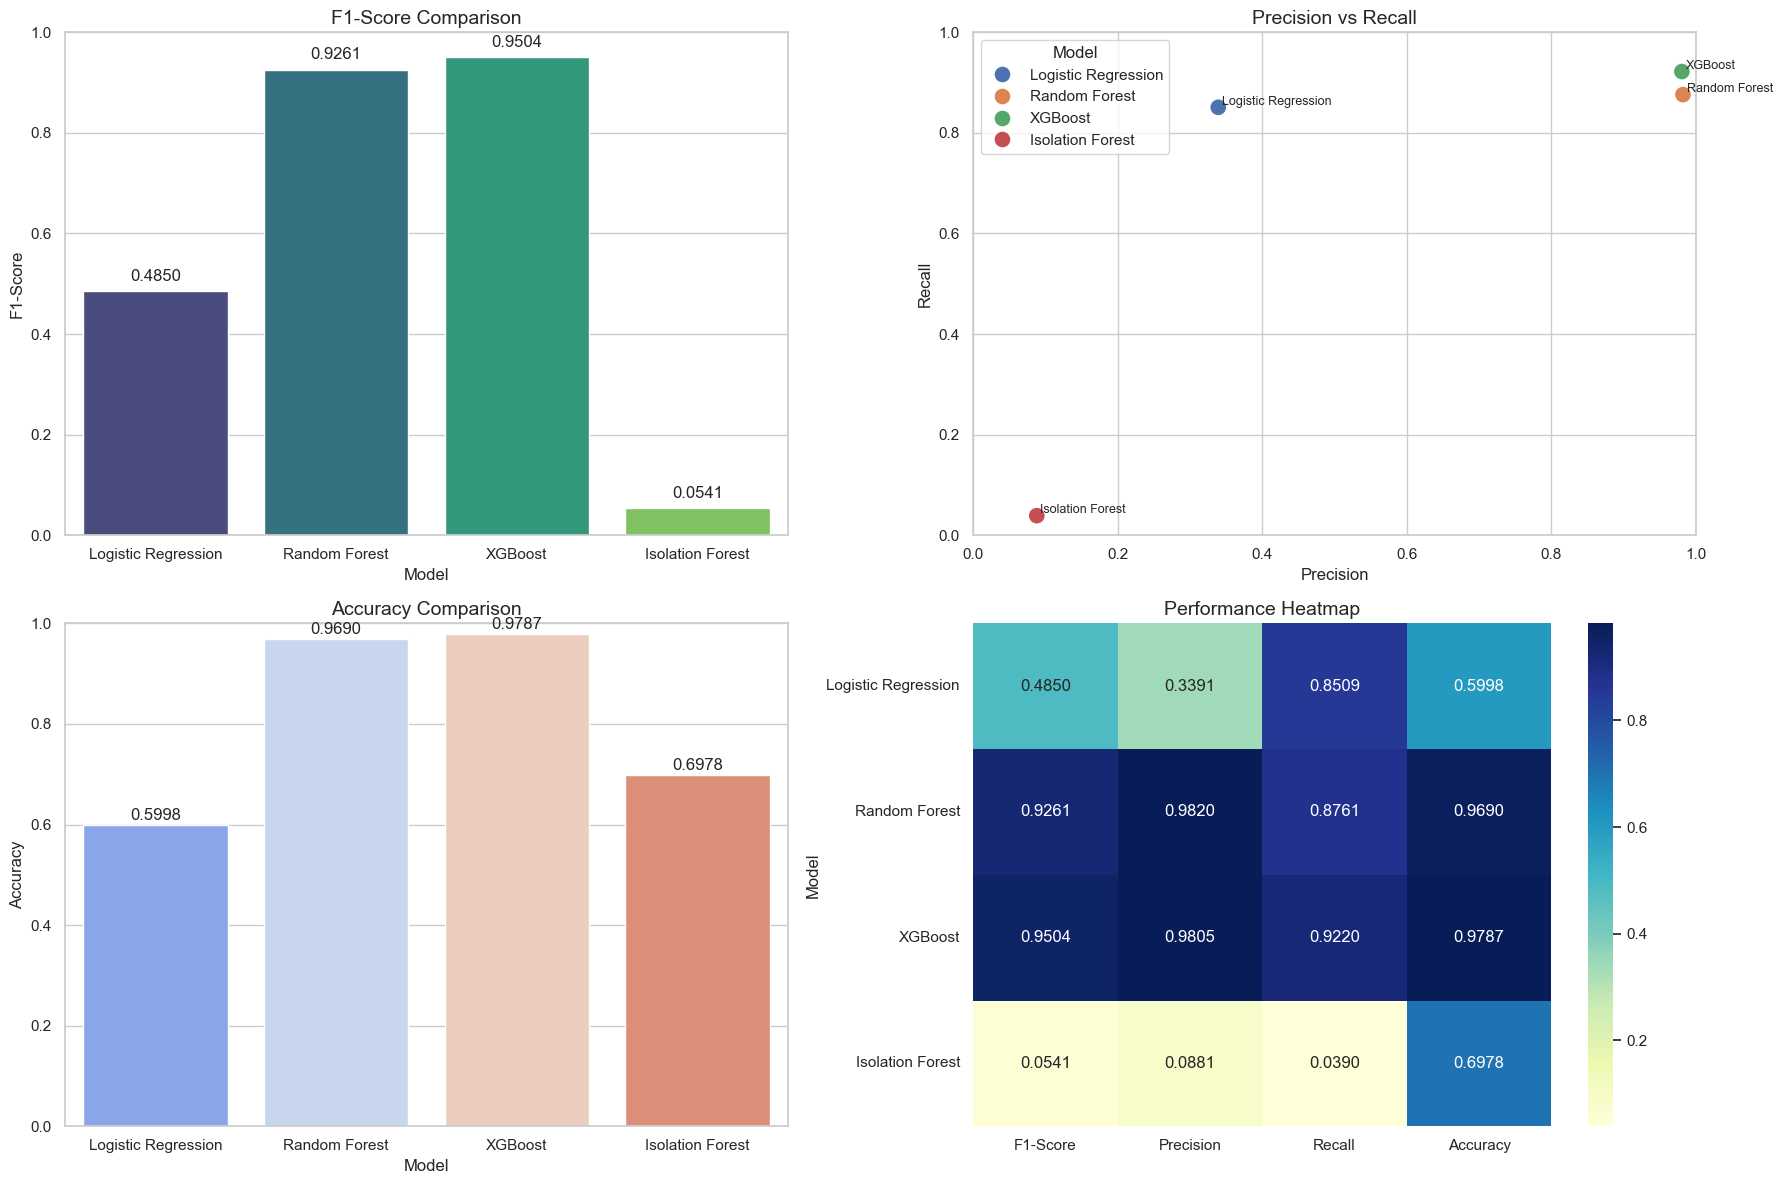

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Convert results to DataFrame
# =========================
df_models = pd.DataFrame(model_performance)

# =========================
# Visualization Style
# =========================
sns.set(style="whitegrid")

# =========================
# Create ONE BIG FIGURE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# =========================================================
# 1. F1-Score Comparison
# =========================================================
sns.barplot(
    data=df_models,
    x="Model",
    y="F1-Score",
    hue="Model",
    palette="viridis",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("F1-Score Comparison", fontsize=14)
axes[0, 0].set_xlabel("Model")
axes[0, 0].set_ylabel("F1-Score")
axes[0, 0].set_ylim(0, 1)

# Add labels
for i, v in enumerate(df_models["F1-Score"]):
    axes[0, 0].text(i, v + 0.02, f"{v:.4f}", ha='center')

# =========================================================
# 2. Precision vs Recall Scatter Plot
# =========================================================
sns.scatterplot(
    data=df_models,
    x="Precision",
    y="Recall",
    hue="Model",
    s=150,
    ax=axes[0, 1]
)

for i in range(len(df_models)):
    axes[0, 1].text(
        df_models["Precision"][i] + 0.005,
        df_models["Recall"][i] + 0.005,
        df_models["Model"][i],
        fontsize=9
    )

axes[0, 1].set_title("Precision vs Recall", fontsize=14)
axes[0, 1].set_xlabel("Precision")
axes[0, 1].set_ylabel("Recall")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1)

# =========================================================
# 3. Accuracy Comparison
# =========================================================
sns.barplot(
    data=df_models,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="coolwarm",
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Accuracy Comparison", fontsize=14)
axes[1, 0].set_xlabel("Model")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylim(0, 1)

# Add labels
for i, v in enumerate(df_models["Accuracy"]):
    axes[1, 0].text(i, v + 0.01, f"{v:.4f}", ha='center')

# =========================================================
# 4. Heatmap of Metrics
# =========================================================
heatmap_data = df_models.set_index("Model")

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Performance Heatmap", fontsize=14)

# =========================
# Adjust Layout
# =========================
plt.tight_layout()

# =========================
# SAVE EVERYTHING IN ONE IMAGE
# =========================
fig.savefig(
    "all_model_visualizations.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

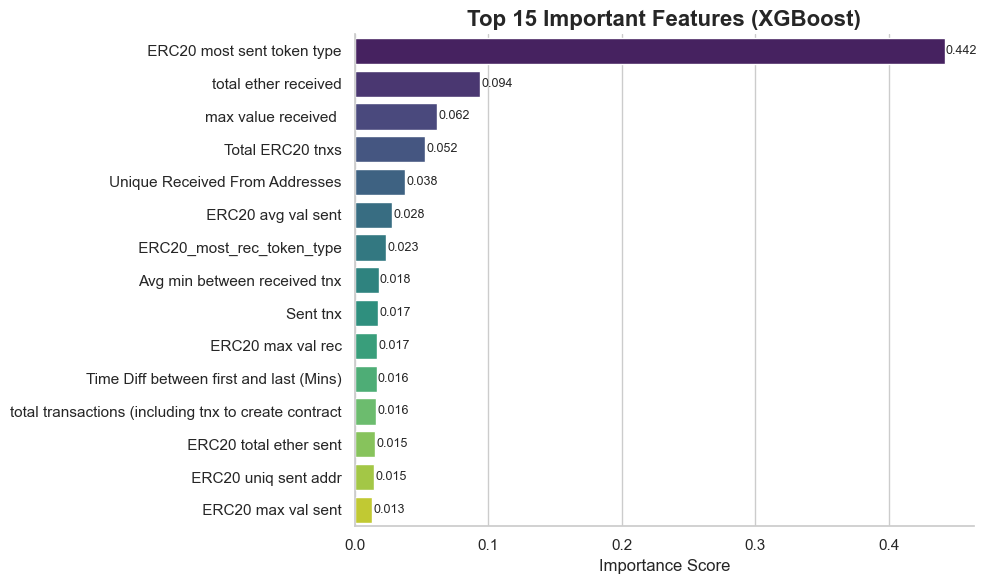

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier

# ============================================================================
# TRAIN XGBOOST MODEL
# ============================================================================

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

importances = xgb_model.feature_importances_
features = X_train.columns

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

# Sort descending
df_imp = df_imp.sort_values(
    by="Importance",
    ascending=False
)

# Top N features
top_n = 15
df_top = df_imp.head(top_n)

# ============================================================================
# VISUALIZATION
# ============================================================================

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_top,
    y="Feature",
    x="Importance",
    hue="Feature",
    palette="viridis",
    legend=False
)

# Title
plt.title(
    "Top 15 Important Features (XGBoost)",
    fontsize=16,
    fontweight='bold'
)

# Axis labels
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("")

# Add value labels
for i, value in enumerate(df_top["Importance"]):
    ax.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va='center',
        fontsize=9
    )

# Remove top/right border
sns.despine()

# Auto layout
plt.tight_layout()

# Save high-quality image
plt.savefig(
    "xgboost_feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()